In [1]:
import numpy as np
import bluepysnap as bp
import matplotlib.pyplot as plt
%matplotlib ipympl

In [2]:
s = bp.Simulation('simulation_config.json')
c = s.circuit

In [3]:
somas = c.nodes['S1nonbarrel_neurons'].get('hex0',properties = ['x','y','z'])

In [4]:
choice = np.random.choice(len(somas),1000,replace=False)

In [5]:
import pandas as pd
npPositions = pd.read_csv('lfp_fullNeuropixels.csv')[['x','y','z']]

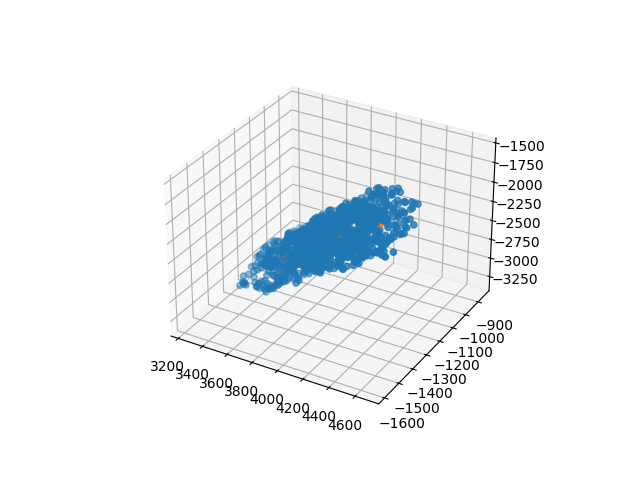

In [6]:
plt.figure()
ax = plt.subplot(projection='3d')
ax.scatter(somas.iloc[choice,0],somas.iloc[choice,1],somas.iloc[choice,2])
ax.scatter(npPositions['x'],npPositions['y'],npPositions['z'])

In [7]:
import MEAutility as MEA

In [8]:
probe = MEA.return_mea("Neuropixels-384")

In [9]:
probe1 = MEA.return_mea("Neuropixels-384")

In [10]:
from bluerecording.utils import alignmentInfo

In [11]:
center, azimuth, elevation = alignmentInfo('simulation_config.json','hex0')

In [12]:
def alignmentInfo(path_to_simconfig,target):

    from bluerecording.utils import getPopulationObject
    from sklearn.decomposition import PCA

    '''
    Gets loction and angle information in order to align a probe with long axis of of the specified target (typically a cortical column)
    '''
    
    population = getPopulationObject(path_to_simconfig)
    
    somaPos = population.get(properties=['x','y','z'],group=target) # Gets soma position
    
    center = np.mean(somaPos,axis=0).values
    
    pca = PCA(n_components=3)
    pca.fit(somaPos)
    main_axis = pca.components_[0]
    
    elevation = np.arctan2(main_axis[2], np.sqrt(main_axis[0]**2+main_axis[1]**2))
    azimuth = np.arctan2(main_axis[1],main_axis[0])
    
    return center, azimuth, elevation

In [13]:
elevation

0.6700190047620722

In [14]:
elevation1

NameError: name 'elevation1' is not defined

In [15]:
center1, azimuth1, elevation1 = alignmentInfo('simulation_config.json','hex0')

In [16]:
def repositionElectrode(probe,center,azimuth,elevation):

    probe.rotate([0,1,0],elevation*180/np.pi)
    probe.rotate([0,0,1],azimuth*180/np.pi)
    probe.move(center)

    return(probe)

In [17]:
repositionElectrode(probe, center, azimuth, elevation)
repositionElectrode(probe1, center1, azimuth1, elevation1)

In [18]:
electrodePositions = probe.positions
electrodePositions1 = probe1.positions

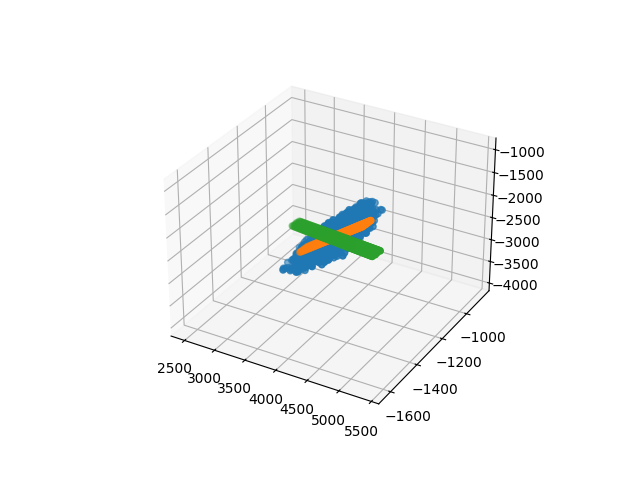

In [20]:
plt.figure()
ax = plt.subplot(projection='3d')
ax.scatter(somas.iloc[choice,0],somas.iloc[choice,1],somas.iloc[choice,2])
ax.scatter(electrodePositions[:,0],electrodePositions[:,1],electrodePositions[:,2])
ax.scatter(electrodePositions1[:,0],electrodePositions1[:,1],electrodePositions1[:,2])